In [1]:
#setup
import pandas as pd
import matplotlib.pyplot as plt

bookings = pd.read_csv("../data/bookings.csv")
passengers = pd.read_csv("../data/passengers.csv")
payments = pd.read_csv("../data/payments.csv")

print("Datasets loaded.")

Datasets loaded.


In [2]:
#basic overview
print(bookings.head())
print(passengers.head())
print(payments.head())

print("Bookings shape:", bookings.shape)
print("Passengers shape:", passengers.shape)
print("Payments shape:", payments.shape)

   booking_id              ship                booking_date  \
0  1000000000  Oceanic Explorer  2025-10-28 21:49:00.650945   
1  1000000001       Sea Voyager  2025-08-12 21:49:00.650993   
2  1000000002    Atlantic Dream  2025-03-26 21:49:00.651021   
3  1000000003       Sea Voyager  2025-10-08 21:49:00.651034   
4  1000000004    Atlantic Dream  2025-12-01 21:49:00.651048   

                 sailing_date  occupants cabin_type  total_fare  
0  2026-03-08 21:49:00.650945          1   Interior     1201.00  
1  2025-09-15 21:49:00.650993          3   Interior     2871.20  
2  2025-04-07 21:49:00.651021          2      Suite     6150.27  
3  2025-12-11 21:49:00.651034          3      Suite     5653.92  
4  2026-05-22 21:49:00.651048          3    Balcony       -4.79  
   passenger_id  booking_id     passenger_name gender  passenger_email
0   10000000000  1000000000  Guest_10000000000      F  user0@email.com
1   10000000010  1000000001  Guest_10000000010      F  user0@email.com
2   10000000

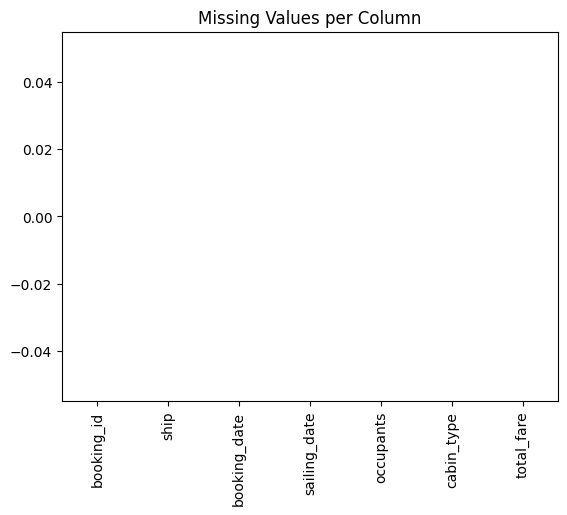

In [3]:
#missing
missing = bookings.isnull().sum()

missing.plot(kind="bar", title="Missing Values per Column")
plt.show()

In [4]:
#duplicates analysis
duplicates = bookings.duplicated().sum()
print("Duplicate bookings:", duplicates)

Duplicate bookings: 0


In [5]:
#business rule validation
#  -invalid sailing dates
invalid_dates = (bookings["sailing_date"] < bookings["booking_date"]).sum()
print("Invalid sailing dates:", invalid_dates)

Invalid sailing dates: 463


In [6]:
#  -negative fare prices
negative_prices = (bookings["total_fare"] < 0).sum()
print("Negative fares:", negative_prices)

Negative fares: 462


In [7]:
#cross-table validation
#  -orphan passengers 
invalid_passengers = passengers[
    ~passengers["booking_id"].isin(bookings["booking_id"])
]

print("Orphan passengers:", len(invalid_passengers))

Orphan passengers: 0


In [8]:
#  -payment mismatch
payment_sum = payments.groupby("booking_id")["payment_amount"].sum()

merged = bookings.set_index("booking_id").join(payment_sum)

overpaid = (merged["payment_amount"] > merged["total_fare"]).sum()

print("Overpaid bookings:", overpaid)

Overpaid bookings: 5815


In [9]:
#data quality score
total_issues = (
    duplicates +
    invalid_dates +
    negative_prices +
    len(invalid_passengers) +
    overpaid
)

total_records = len(bookings)

score = 100 - ((total_issues / total_records) * 100)

print("Data Quality Score:", round(score, 2), "%")

Data Quality Score: 32.6 %


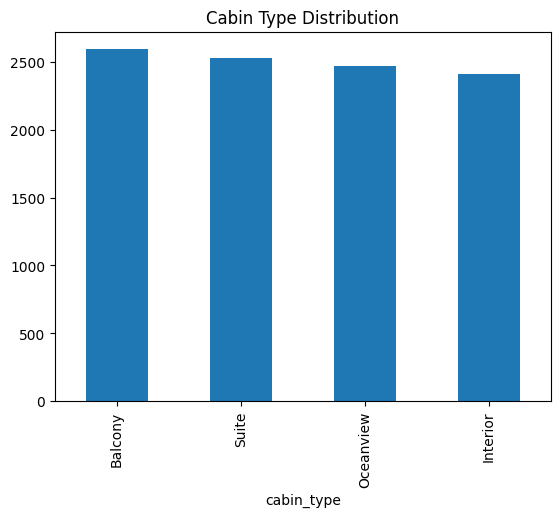

In [10]:
#visualization
#  -booking distribution
bookings["cabin_type"].value_counts().plot(kind="bar", title="Cabin Type Distribution")
plt.show()

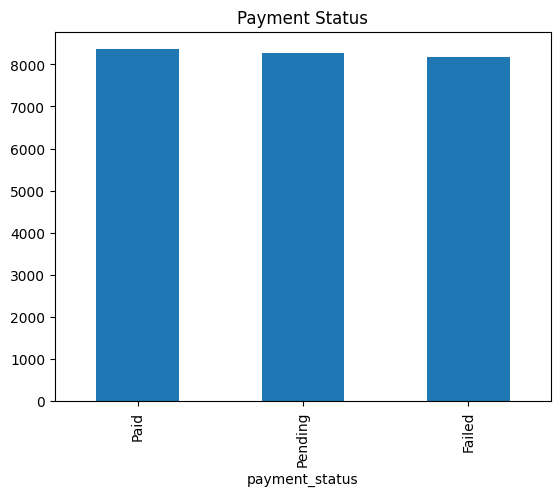

In [11]:
#payment status
payments["payment_status"].value_counts().plot(kind="bar", title="Payment Status")
plt.show()